Text(0.5, 1.0, 'N = 10^6')

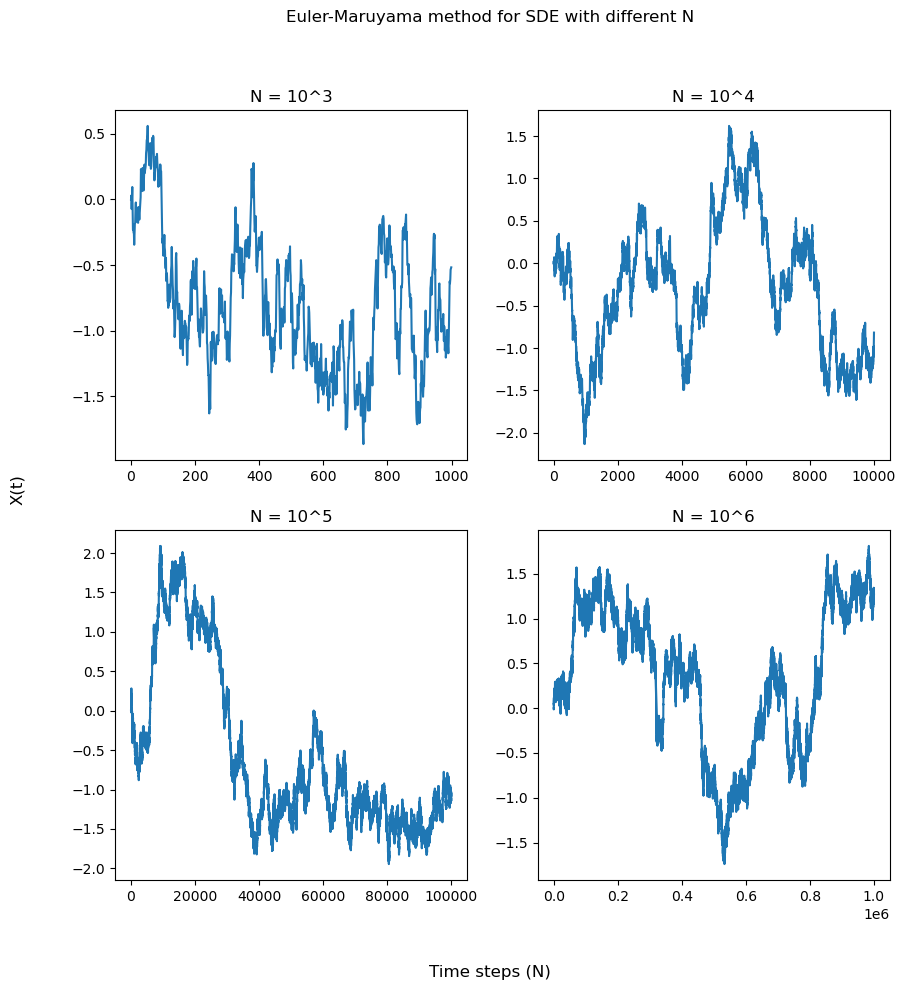

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)\

def euler_maruyama(T, n):
    X = [0]
    deltaT = T/n
    for i in range(1, n):
        X.append(X[i-1] - X[i-1] * (X[i-1] + 1) * (X[i-1] - 1) * deltaT + np.sqrt(deltaT) * rng.normal(0,1))
    return X

fig, ax = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Euler-Maruyama method for SDE with different N")
fig.supxlabel("Time steps (N)") 
fig.supylabel("X(t)")
ax[0,0].plot(euler_maruyama(10, 1000))
ax[0,0].set_title("N = 10^3")
ax[0,1].plot(euler_maruyama(10, 10000))
ax[0,1].set_title("N = 10^4")
ax[1,0].plot(euler_maruyama(10, 100000))
ax[1,0].set_title("N = 10^5")
ax[1,1].plot(euler_maruyama(10, 1000000))
ax[1,1].set_title("N = 10^6")

(0.0, 1.0)

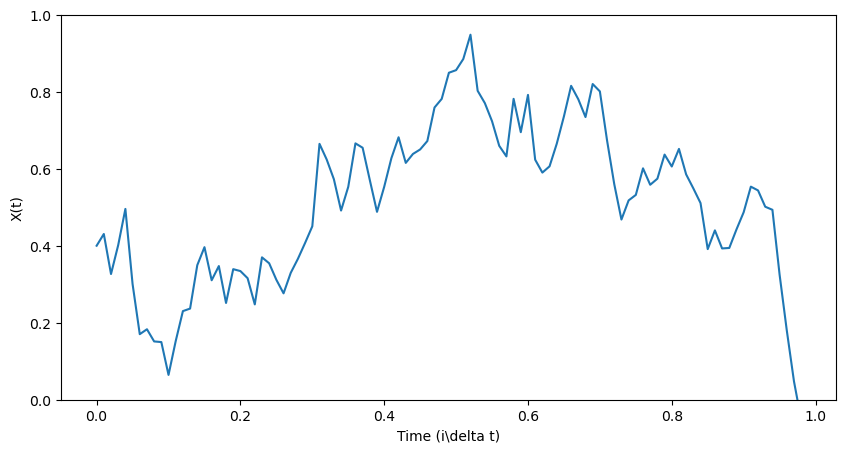

In [46]:
deltaT = 0.01

rng = np.random.default_rng(seed=42)

def euler_maruyama2(y0):
    Y = [y0]
    i = 1
    while Y[i-1] < 1 and Y[i-1] > 0:
        Y.append(Y[i-1] + np.sqrt(deltaT) * rng.normal(0,1))
        i += 1
    return Y, i

Y, i = euler_maruyama2(0.4)
X = np.arange(0, i*deltaT, deltaT)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(X, Y)
ax.set_xlabel(r'Time (i\delta t)')
ax.set_ylabel(r'X(t)')
ax.set_ylim(0, 1)

In [69]:
rng = np.random.default_rng(seed=42)
n = 1000
sum = 0
for i in range(1, n):
    Y, i = euler_maruyama2(0.9)
    X = np.arange(0, i*deltaT, deltaT)
    sum += i 
sum /= n
sum

16.782

Text(0, 0.5, '\\bar T(x_j)')

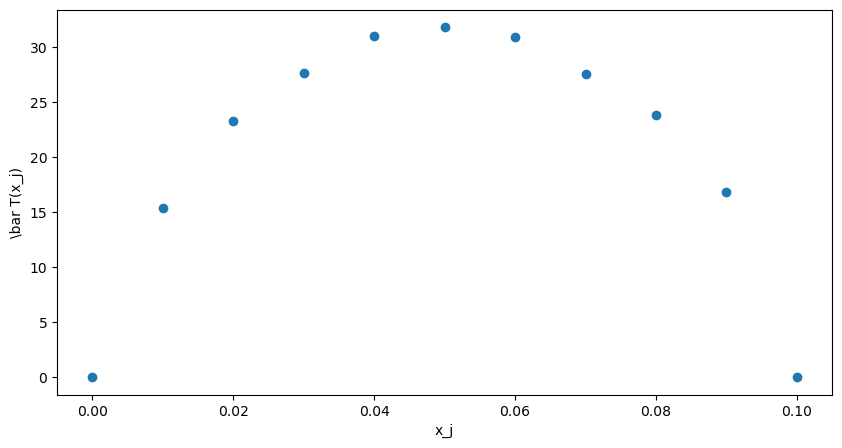

In [72]:
Y = [0, 15.364, 23.218, 27.599, 30.985, 31.786, 30.915, 27.554, 23.818, 16.782, 0]
X = np.arange(0, 11*deltaT, deltaT)
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(X, Y)
ax.set_xlabel("x_j")
ax.set_ylabel(r"\bar T(x_j)")